In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import json
from scipy import integrate

In [35]:
model_variants = [
    "yolov5nu.pt_pruned-0.3",
    "yolov5nu.pt_pruned-0.5",
    "yolov5su.pt_pruned-0.3",
    "yolov5su.pt_pruned-0.5",
    "yolov5mu.pt_pruned-0.3",
    "yolov5mu.pt_pruned-0.5",
    "yolov5lu.pt_pruned-0.3",
    "yolov5lu.pt_pruned-0.5",
]
results_dir = Path("raw_data/pytorch_pruned_models")


In [36]:
def read_model(model_name, results_dir):
    short_model_name = model_name[:11]
    power_df = pd.read_csv(results_dir / model_name / f"{short_model_name}_power_log.log", names=["time", "voltage", "current"], parse_dates=[0])
    with open(results_dir / model_name / f"{short_model_name}_pytorch.json") as f:
        timings = json.load(f)
    with open(results_dir / model_name / "validation_results.json") as f:
        results = json.load(f)
    return power_df, timings, results

def read_idle_power(results_dir):
    with open(results_dir / "idling_power.json") as f:
        power = json.load(f)
    return power["avg_idle_power"]


In [37]:
idle_power = read_idle_power(results_dir)

In [38]:
def calculate_metrics(model_name: str, idle_power: float, results_dir: Path, plot=False):
    """Calculates metrics and returns a dict with all metrics for a given model measurements.

    'Active' part is defined as part of the time series between the first and the last instance 
    of power readings above a certain arbitrary threshold, e.g. 1 W.
    

    Returns: 
        a dict of:
        "mean_active_power": mean power of the 'active' part of the measurements in W
        "max_active_power": max power of the 'active' part of the measurements in W
        "wall_time": time we recorded before and after validation method was called in sec
        "active_time": time taken by the 'active' part of the measurements in sec
        "inference_time": inference time as reported by ultralytics in sec
        "mean_active_energy": energy according to mean power and active time in J
        "max_active_energy": energy according to max power and active time in J
        "mean_inference_energy": energy according to mean power and inference time in J
        "max_inference_energy": energy according to max power and inference time in J
        "integrated_energy": energy by integration (trapezoid method) in J
    """
    power_df, timings, ultralytics_results = read_model(model_name, results_dir)
    
    start_time = pd.to_datetime(timings["start_time"], unit='s')
    end_time = pd.to_datetime(timings["end_time"], unit='s')
    wall_time = (end_time - start_time).total_seconds()
    inference_time = ultralytics_results["speed"]["inference"]
    power_profile = power_df[(power_df.time >= start_time) & (power_df.time <= end_time)]
    # Get power profile subtracting the idle power
    power_profile.loc[:, ["power"]] = (power_profile.current * power_profile.voltage - idle_power) / 10**6

    # Get framework overhead power (the low parts before and after active part)
    framework_power_overhead = power_profile.power.iloc[:10000].mean()
    power_profile.loc[:, "power"] = (power_profile.power - framework_power_overhead)
    filtered_time = power_profile[power_profile.power > 1].time
    active_power_profile = power_profile.loc[(power_df.time >= filtered_time.min()) & (power_df.time <= filtered_time.max())]

    if plot:
        sns.lineplot(power_profile, x="time", y="power")
        sns.lineplot(active_power_profile, x="time", y="power")
        plt.show()

    mean_active_power = active_power_profile.power.mean()
    max_active_power = active_power_profile.power.max()
    active_time = (active_power_profile.time.iloc[-1] - active_power_profile.time.iloc[0]).total_seconds()
    integrated_energy = integrate.trapezoid(active_power_profile.power, x=active_power_profile.time.apply(lambda x: x.timestamp()))
    result = {
        "mean_active_power": mean_active_power,
        "max_active_power": max_active_power,
        "wall_time": wall_time,
        "active_time": active_time,
        "inference_time": inference_time,
        "mean_active_energy": mean_active_power * active_time,
        "max_active_energy": max_active_power * active_time,
        "mean_inference_energy": mean_active_power * inference_time,
        "max_inference_energy": max_active_power * inference_time,
        "integrated_energy": integrated_energy,
    }
    result.update(ultralytics_results["metrics"])
    return result


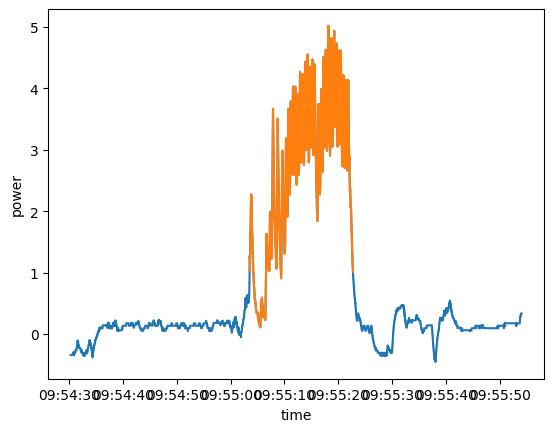

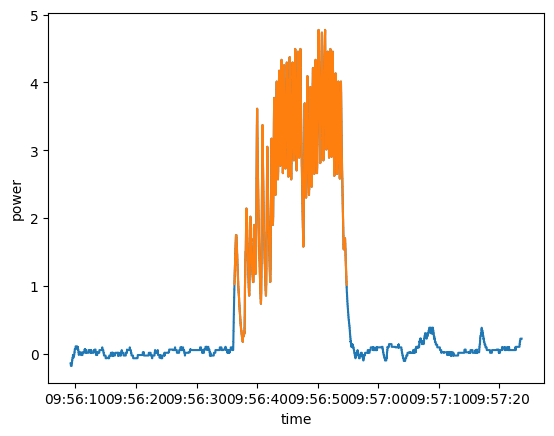

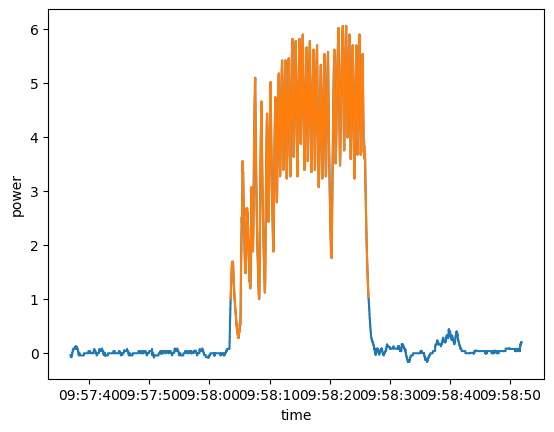

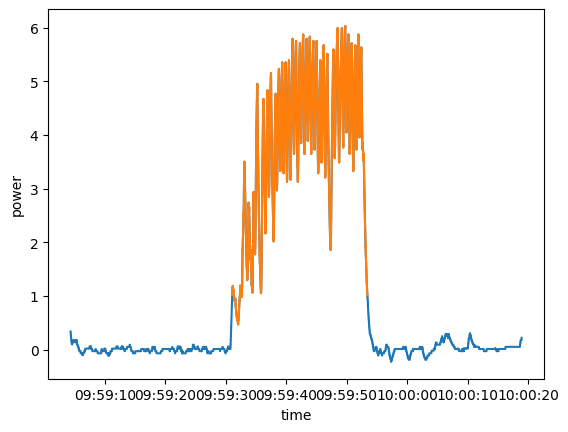

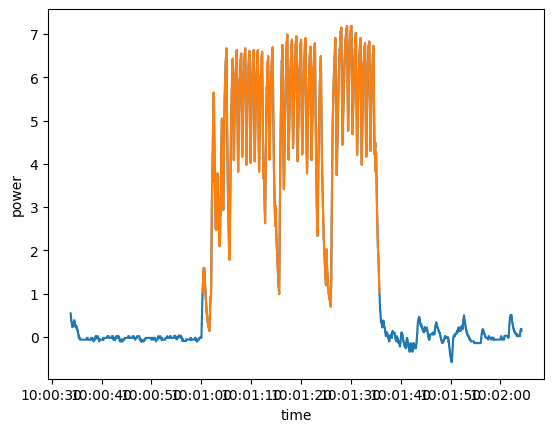

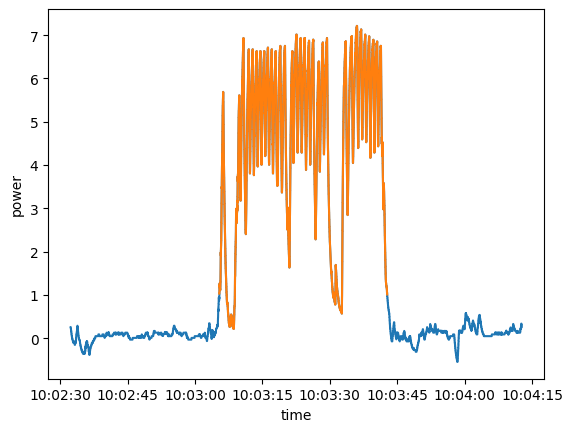

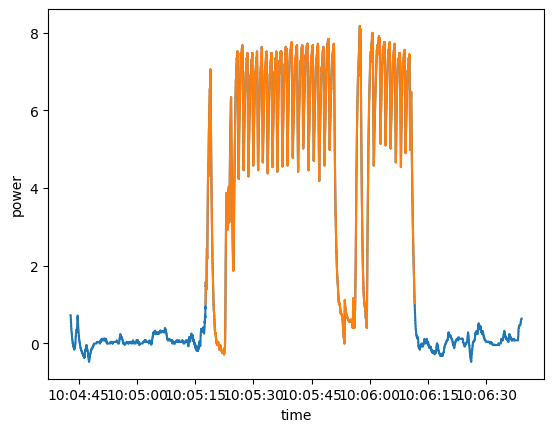

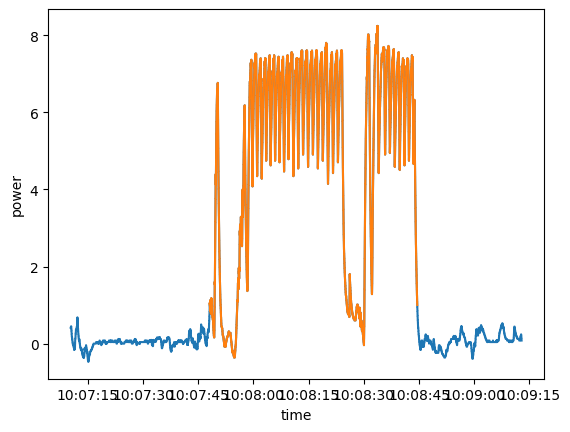

In [39]:
measurements_df = pd.DataFrame({model_name: calculate_metrics(model_name, idle_power, results_dir, plot=True) for model_name in model_variants}).T

In [40]:
measurements_df

,mean_active_power,max_active_power,wall_time,active_time,inference_time,mean_active_energy,max_active_energy,mean_inference_energy,max_inference_energy,integrated_energy,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),fitness
yolov5nu.pt_pruned-0.3,2.648842,5.015609,83.692570,19.188476,16.553800,50.827250,96.241895,43.848408,83.027391,50.732751,0.642915,0.437095,0.503022,0.355858,0.370575
yolov5nu.pt_pruned-0.5,2.661954,4.773014,74.444077,18.518669,16.058589,49.295848,88.389866,42.747229,76.647872,49.497784,0.583953,0.414023,0.465485,0.317798,0.332566
yolov5su.pt_pruned-0.3,3.716790,6.054242,74.944812,22.918680,24.432146,85.183927,138.755237,90.809161,147.918124,85.205481,0.714067,0.550429,0.618984,0.460445,0.476299
yolov5su.pt_pruned-0.5,3.786577,6.034447,74.582736,22.359007,24.480885,84.664093,134.924249,92.698745,147.728607,84.627994,0.671930,0.521032,0.592720,0.434635,0.450444
yolov5mu.pt_pruned-0.3,4.722002,7.184721,90.455466,35.487713,50.787711,167.573048,254.969331,239.819666,364.895552,168.317627,0.695954,0.629501,0.668704,0.516144,0.531400
yolov5mu.pt_pruned-0.5,4.567072,7.214232,100.347971,37.342751,52.938601,170.547020,269.399272,241.774386,381.911357,170.857393,0.694973,0.618641,0.666864,0.508802,0.524608
yolov5lu.pt_pruned-0.3,5.166054,8.176364,116.222600,53.909054,81.876027,278.497097,440.780061,422.975997,669.448220,280.119300,0.738206,0.637732,0.707220,0.553795,0.569138
yolov5lu.pt_pruned-0.5,4.879704,8.244242,122.534935,56.395240,83.082607,275.192058,464.935986,405.418501,684.953091,277.862012,0.712798,0.653296,0.701091,0.544064,0.559766


In [41]:
baseline_model_variants = [
    "yolov5nu.pt",
    "yolov5su.pt",
    "yolov5mu.pt",
    "yolov5lu.pt",
]
baseline_results_dir = Path("raw_data/prebuilt_models")

baseline_idle_power = read_idle_power(results_dir)
baseline_measurements_df = pd.DataFrame({model_name: calculate_metrics(model_name, baseline_idle_power, baseline_results_dir, plot=False) for model_name in baseline_model_variants}).T



<Axes: title={'center': 'YOLOv5 Baseline'}, xlabel='Valdation Energy Consumption (J)', ylabel='mAP50-95'>

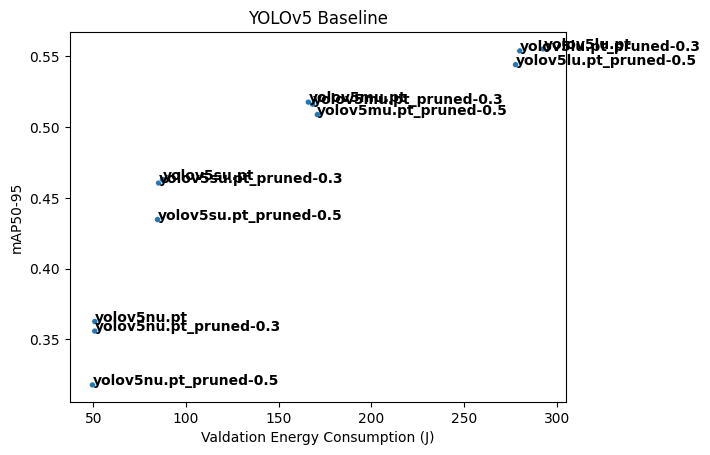

In [45]:
def scatter_text(x, y, text_column, data, title, xlabel, ylabel):
    """Scatter plot with country codes on the x y coordinates
       Based on this answer: https://stackoverflow.com/a/54789170/2641825"""
    # Create the scatter plot
    p1 = sns.scatterplot(x=x, y=y, data=data, size = 8, legend=False)
    # Add text besides each point
    for line in range(0,data.shape[0]):
         p1.text(data[x][line]+0.01, data[y][line], 
                 data[text_column][line], horizontalalignment='left', 
                 size='medium', color='black', weight='semibold')
    # Set title and axis labels
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    return p1

scatter_text(
    "integrated_energy", 
    "metrics/mAP50-95(B)", 
    "index", 
    data=pd.concat([measurements_df, baseline_measurements_df]).reset_index(), 
    title="YOLOv5 Baseline", 
    xlabel="Valdation Energy Consumption (J)", 
    ylabel="mAP50-95",
)


In [46]:
measurements_df.to_csv("raw_data/pytorch_pruned_models_measurements.csv")